# Simulation Playground Notebook
This notebook is designed as a easy einterface to call the functions that we have defined

In [23]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

import torch.optim as optim
import torch.nn as nn
import torch

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_participants_info, load_event_descriptions, load_behavioral_data, preprocess_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data Preparation
Let's prepare some data first to fit our model. We are specifically using ["Locus coeruleus activity strengthens prioritized memories under arousal"](https://openneuro.org/datasets/ds002011/versions/1.0.0) dataset fror now.

In [24]:
DATASET_PATH = "data"
participants_df = load_participants_info(DATASET_PATH)
load_event_descriptions(DATASET_PATH)

df_behavior = load_behavioral_data(DATASET_PATH, "01")
for idx in range(2,11):
    sample_participant = f"0{idx}"
    df = load_behavioral_data(DATASET_PATH, sample_participant)
    df_behavior = pd.concat([df, df_behavior], ignore_index=True)

Let's preprocess our data first

In [25]:
X, Y, X_tensor, Y_tensor, scaler_X, scaler_Y, df_clean = preprocess_data(df_behavior)

X Shape: torch.Size([1699, 7]), Y Shape: torch.Size([1699])
Y Min: -1.0, Y Max: 1.0


In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(X_tensor, Y_tensor, test_size=0.2, random_state=42)

# Training

In [27]:
from train import (train_feed_forward_nn,
                   train_vanilla_rnn,
                   train_vanilla_lstm,
                   train_vanilla_lc_model,
                   train_lstm_lc_model,
                   train_ff_controller,
                   train_ff_uncertain_controller
                   )
from analysis.evaluation import evaluate_model

## Fully Connected Neural Network

To illustrate our idea, we want to train 2 models from math and computer science, which is our vanilla feed forward networks and an recurrent networks.

Epoch 0, Loss: 0.06947154551744461
Epoch 100, Loss: 0.046271249651908875
Epoch 200, Loss: 0.04408590868115425
Epoch 300, Loss: 0.04341956228017807
Epoch 400, Loss: 0.04329643398523331
Epoch 500, Loss: 0.04166732355952263
Epoch 600, Loss: 0.04147067293524742
Epoch 700, Loss: 0.04093321040272713
Epoch 800, Loss: 0.040161408483982086
Epoch 900, Loss: 0.04052235558629036
Epoch 1000, Loss: 0.03971414640545845
Epoch 1100, Loss: 0.03946668654680252
Epoch 1200, Loss: 0.040957167744636536
Epoch 1300, Loss: 0.03962308540940285
Epoch 1400, Loss: 0.03934154659509659
Epoch 1500, Loss: 0.03884008526802063
Epoch 1600, Loss: 0.03869132325053215
Epoch 1700, Loss: 0.038713231682777405
Epoch 1800, Loss: 0.03896023705601692
Epoch 1900, Loss: 0.03853081166744232
Training complete!
Evaluating Model: FeedForwardNN


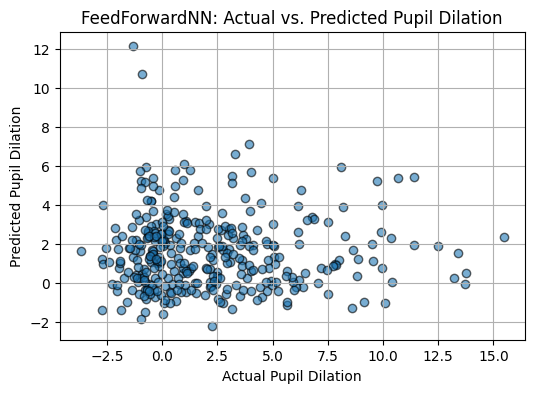

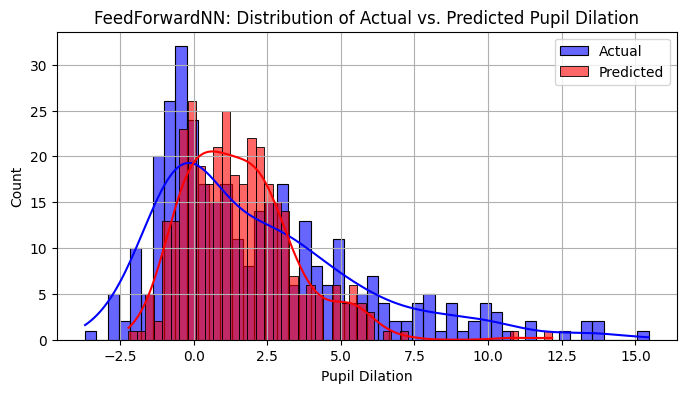

FeedForwardNN - Pearson Correlation: -0.0105


In [28]:
model_ff = train_feed_forward_nn(X_train, Y_train,epochs=2000)
evaluate_model(model_ff, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## Recurent Neural Networks

We will  do the same thing with an recurrent neural network

In [29]:
# model_rnn = train_vanilla_rnn(X_train, Y_train, epochs=2000)
# evaluate_model(model_rnn, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LSTM Models

In [30]:
# model_lstm = train_vanilla_lstm(X_train, Y_train, epochs=5000, hidden_dim=12)
# evaluate_model(model_lstm, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LCNECortex Fitter Model

Now coming to our customized LCNECortex model

Epoch 0, Loss: 0.25583410263061523


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100, Loss: 0.039569929242134094
Epoch 200, Loss: 0.03889666497707367
Epoch 300, Loss: 0.016700971871614456
Epoch 400, Loss: 0.026335835456848145
Epoch 500, Loss: 0.03346186503767967
Epoch 600, Loss: 0.044970184564590454
Epoch 700, Loss: 0.04388931766152382
Epoch 800, Loss: 0.05650779604911804
Epoch 900, Loss: 0.0444725938141346
Epoch 1000, Loss: 0.05526137724518776
Epoch 1100, Loss: 0.0255647711455822
Epoch 1200, Loss: 0.03916757181286812
Epoch 1300, Loss: 0.029446730390191078
Epoch 1400, Loss: 0.044659413397312164
Epoch 1500, Loss: 0.043662577867507935
Epoch 1600, Loss: 0.059985365718603134
Epoch 1700, Loss: 0.044160712510347366
Epoch 1800, Loss: 0.0459413081407547
Epoch 1900, Loss: 0.05227981507778168
Training complete!
Evaluating Model: LCNECortexFitter


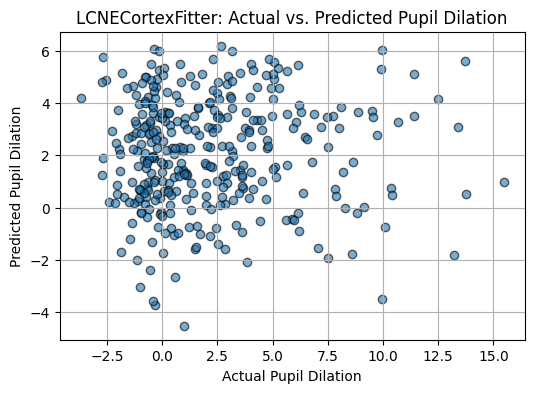

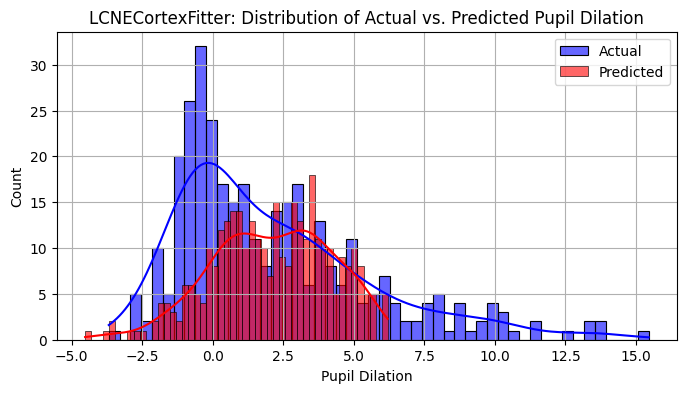

LCNECortexFitter - Pearson Correlation: 0.0383


In [31]:
model_lc_vanilla = train_vanilla_lc_model(X_train, Y_train, epochs=2000)
evaluate_model(model_lc_vanilla, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LSTM LCNECortex Model

In [32]:
# model_lc_lstm = train_lstm_lc_model(X_train, Y_train, epochs=2000, hidden_dim=64)
# evaluate_model(model_lc_lstm, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

# FF Gadget Model

Epoch 0, Loss: 0.091441


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100, Loss: 0.036025
Epoch 200, Loss: 0.013719
Epoch 300, Loss: 0.058746
Epoch 400, Loss: 0.031426
Epoch 500, Loss: 0.019583
Epoch 600, Loss: 0.021813
Epoch 700, Loss: 0.021363
Epoch 800, Loss: 0.030542
Epoch 900, Loss: 0.048618
Epoch 1000, Loss: 0.020905
Epoch 1100, Loss: 0.022034
Epoch 1200, Loss: 0.025824
Epoch 1300, Loss: 0.024547
Epoch 1400, Loss: 0.041917
Epoch 1500, Loss: 0.032739
Epoch 1600, Loss: 0.032132
Epoch 1700, Loss: 0.017251
Epoch 1800, Loss: 0.016518
Epoch 1900, Loss: 0.031265
Epoch 2000, Loss: 0.054423
Epoch 2100, Loss: 0.037000
Epoch 2200, Loss: 0.022287
Epoch 2300, Loss: 0.034658
Epoch 2400, Loss: 0.019801
Epoch 2500, Loss: 0.043991
Epoch 2600, Loss: 0.048990
Epoch 2700, Loss: 0.014852
Epoch 2800, Loss: 0.034791
Epoch 2900, Loss: 0.043402
Epoch 3000, Loss: 0.025088
Epoch 3100, Loss: 0.027831
Epoch 3200, Loss: 0.023133
Epoch 3300, Loss: 0.015855
Epoch 3400, Loss: 0.040732
Early stopping triggered at epoch 3461
Training complete!
Evaluating Model: FFGadgetControl

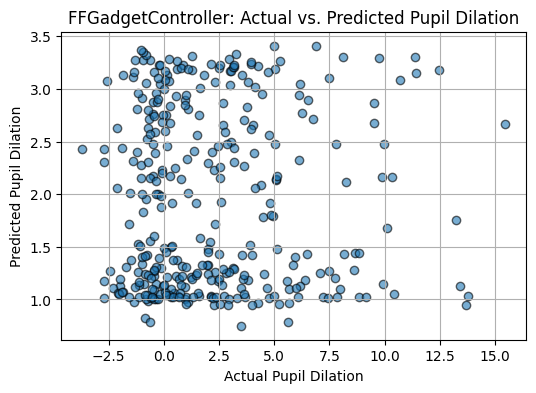

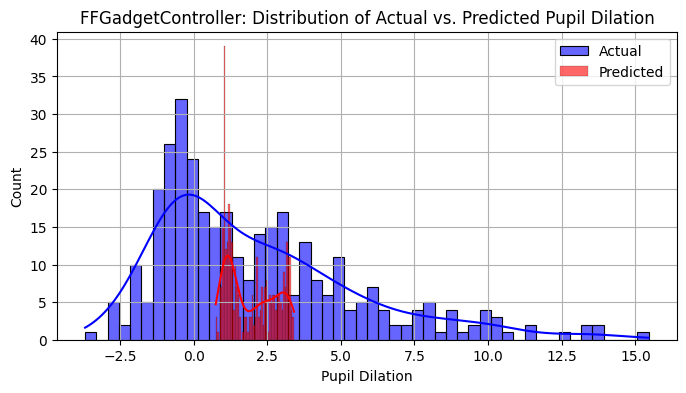

FFGadgetController - Pearson Correlation: 0.0203


In [33]:
ff_gadget = train_ff_controller(X_train, Y_train, epochs=5000, hidden_dim=264)
evaluate_model(ff_gadget, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## Modified Uncertainty GadgetModel

Epoch 0, Loss: 0.056055


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100, Loss: 0.017741
Epoch 200, Loss: 0.028057
Epoch 300, Loss: 0.033430
Epoch 400, Loss: 0.047755
Epoch 500, Loss: 0.035125
Epoch 600, Loss: 0.023724
Epoch 700, Loss: 0.060655
Epoch 800, Loss: 0.030511
Epoch 900, Loss: 0.025076
Epoch 1000, Loss: 0.022139
Epoch 1100, Loss: 0.045327
Epoch 1200, Loss: 0.015688
Epoch 1300, Loss: 0.031061
Epoch 1400, Loss: 0.018054
Epoch 1500, Loss: 0.019113
Epoch 1600, Loss: 0.031656
Epoch 1700, Loss: 0.025488
Epoch 1800, Loss: 0.023116
Epoch 1900, Loss: 0.017143
Epoch 2000, Loss: 0.012857
Epoch 2100, Loss: 0.032830
Epoch 2200, Loss: 0.033058
Epoch 2300, Loss: 0.019494
Epoch 2400, Loss: 0.027726
Epoch 2500, Loss: 0.024635
Epoch 2600, Loss: 0.019160
Early stopping triggered at epoch 2607
Training complete!
Evaluating Model: FFGadgetUncertainController


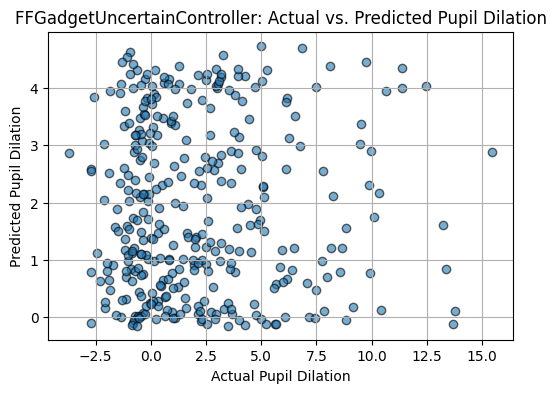

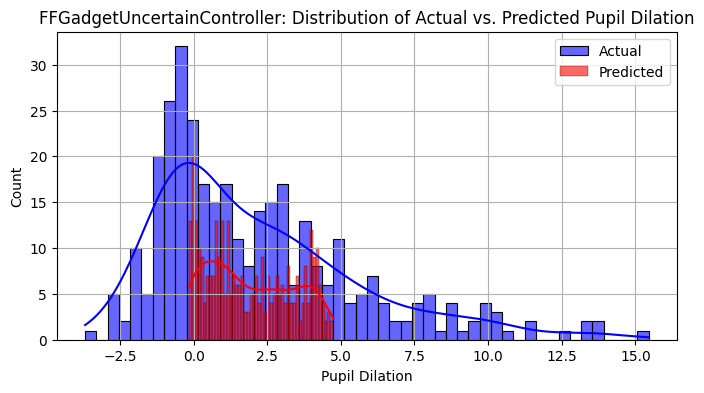

FFGadgetUncertainController - Pearson Correlation: 0.0123


In [34]:
ff_uncertain_gadget = train_ff_uncertain_controller(X_tensor, Y_tensor, epochs=5000, hidden_dim=200)
evaluate_model(ff_uncertain_gadget, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

# Analysis

In [35]:
from analysis.analysis import (pca_lcne_lstm,
                               pca_feed_forward,
                               pca_lcne,
                               pca_lstm,
                               analyze_ff_gadget_activations,
                               evaluate_ff_uncertainty_gadget
)

## Feed-Forward Neural Networks

In [36]:
# pca_feed_forward(model_ff, X_tensor, df_behavior)

## LCNECortex Model

We will see that, though  under fitted with the real data, there are some structureness to the data that we can play around with since we injected mechanistic insights into it.

Text(0.5, 1.0, 'Cortex Activation Distribution')

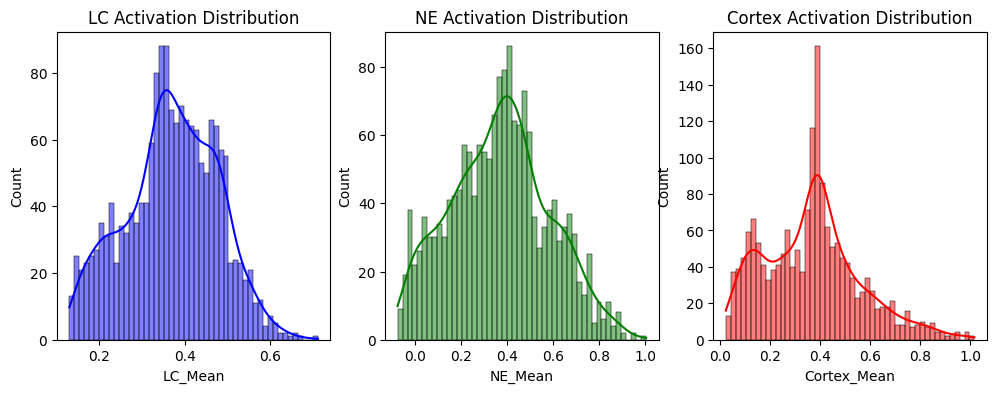

In [37]:
with torch.no_grad():
    prev_LC = torch.zeros(X_tensor.shape[0], model_lc_vanilla.hidden_dim)
    prev_Cortex = torch.zeros(X_tensor.shape[0], model_lc_vanilla.hidden_dim)

    LC_act, NE_act, C_act, Pupil_pred, LC_raw, NE_raw, C_raw = model_lc_vanilla(X_tensor, prev_LC, prev_Cortex, return_activations=True)

act_lc = LC_act.cpu().numpy()
act_ne = NE_act.cpu().numpy()
act_cortex = C_act.cpu().numpy()

df_activations = pd.DataFrame({
    'LC_Mean': act_lc.mean(axis=1),
    'NE_Mean': act_ne.mean(axis=1),
    'Cortex_Mean': act_cortex.mean(axis=1),
    'PupilPred': Pupil_pred.cpu().numpy().squeeze(),
    'ActualPupil': df_clean['Event_PupilDilation'].values  # Ensure this aligns with X_tensor
})

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(df_activations['LC_Mean'], kde=True, bins=50, color='blue')
plt.title("LC Activation Distribution")

plt.subplot(1, 3, 2)
sns.histplot(df_activations['NE_Mean'], kde=True, bins=50, color='green')
plt.title("NE Activation Distribution")

plt.subplot(1, 3, 3)
sns.histplot(df_activations['Cortex_Mean'], kde=True, bins=50, color='red')
plt.title("Cortex Activation Distribution")

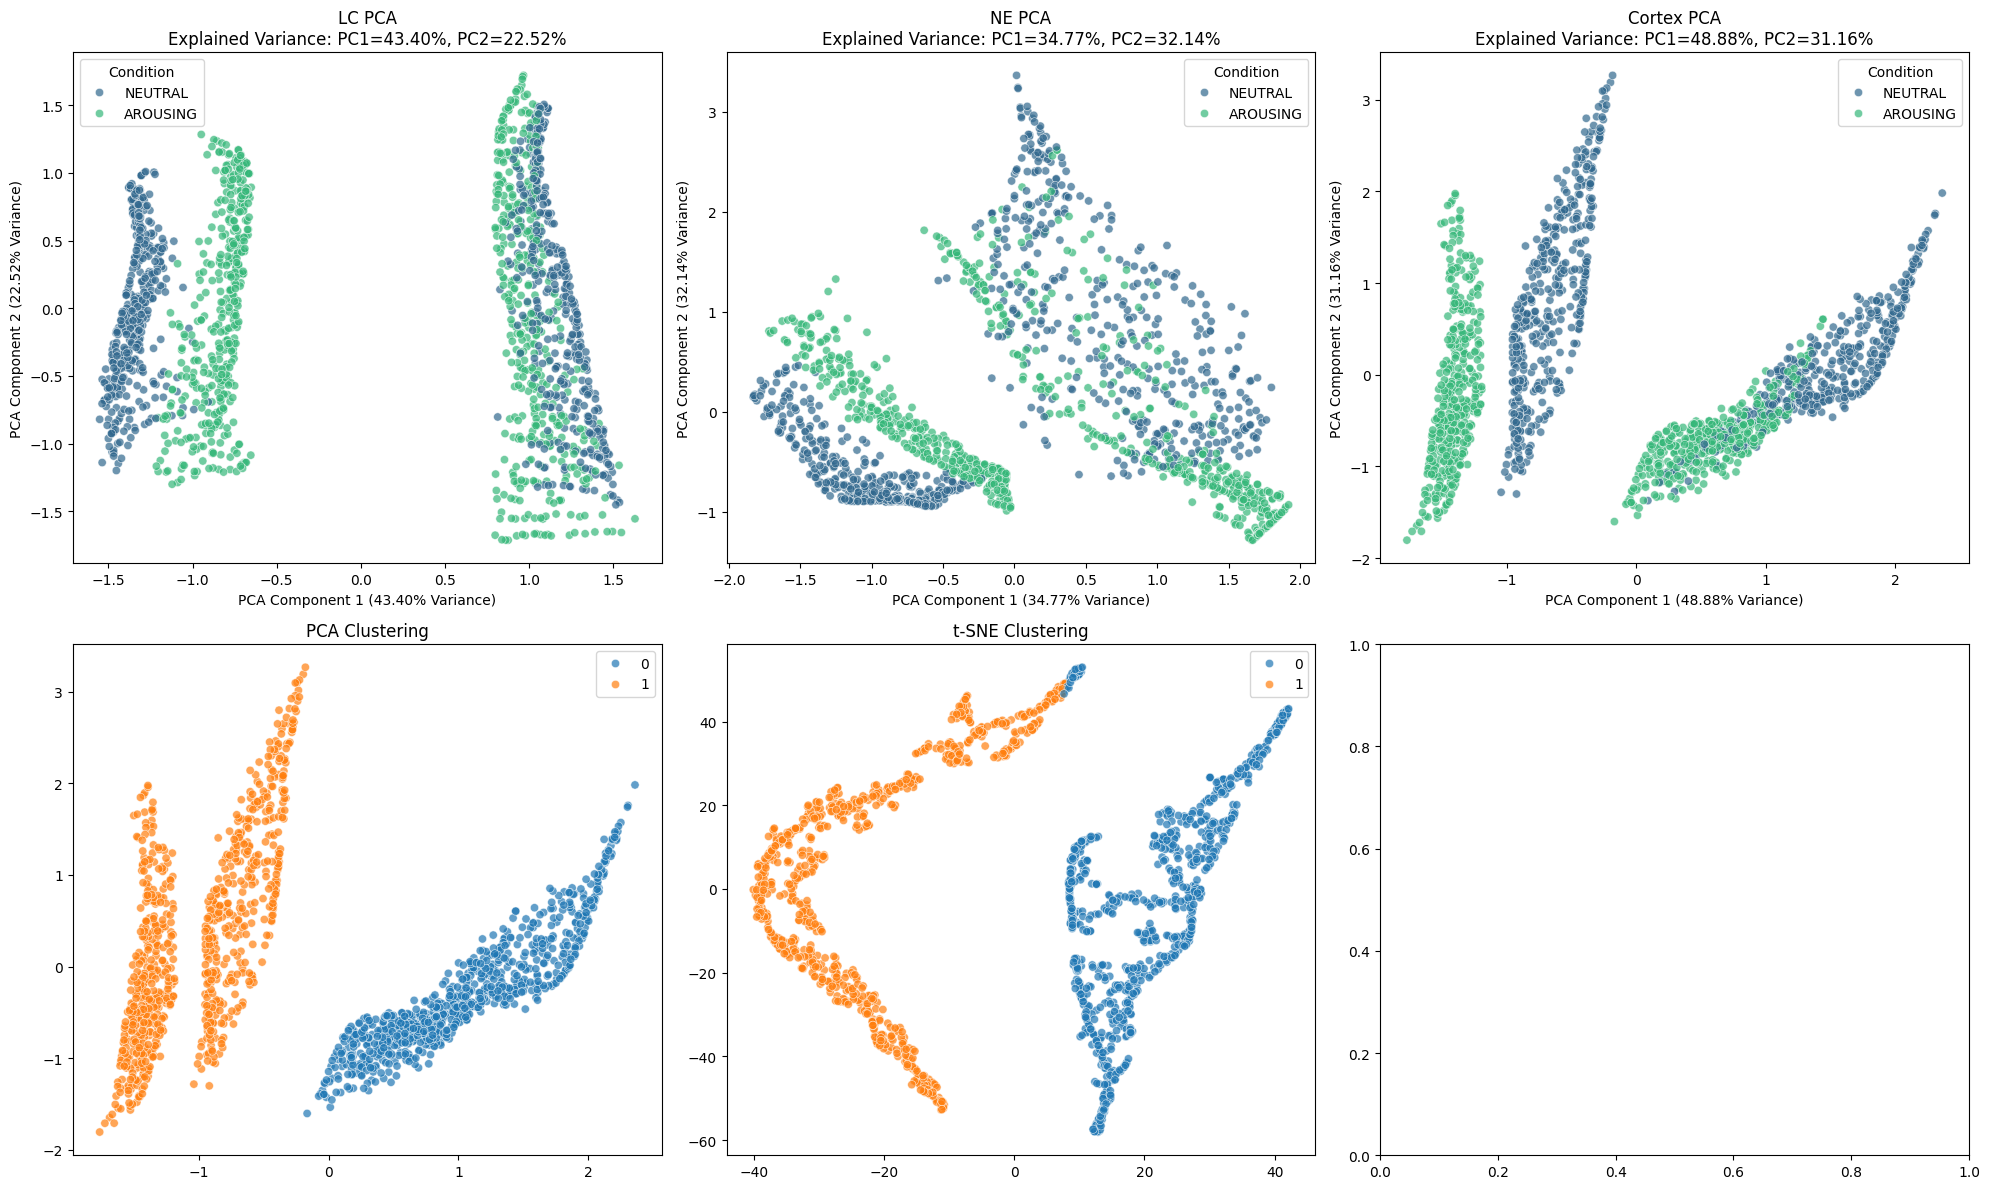

In [38]:
pca_lcne(model_lc_vanilla, X_tensor, df_clean)

## LSTM LCNECortex Model

In [39]:
# pca_lcne_lstm(model_lc_lstm, X_tensor, df_clean)

## Vanilla LSTM Comparison

In [40]:
# pca_lstm(model_lstm, X_test, df_clean)

## FF Gadget Model

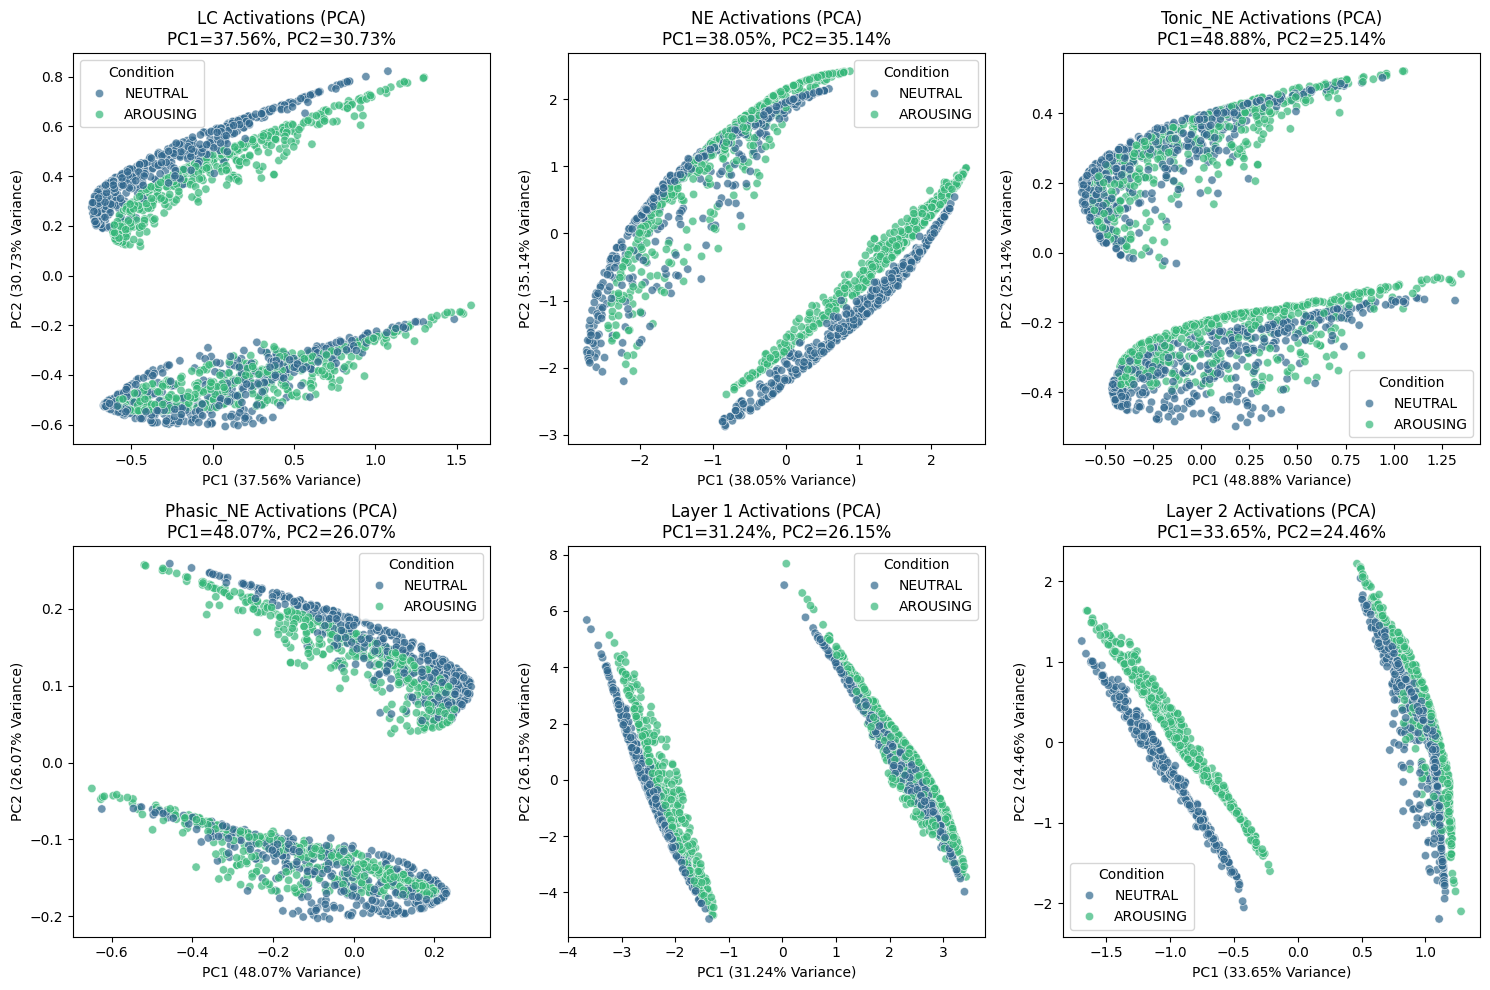

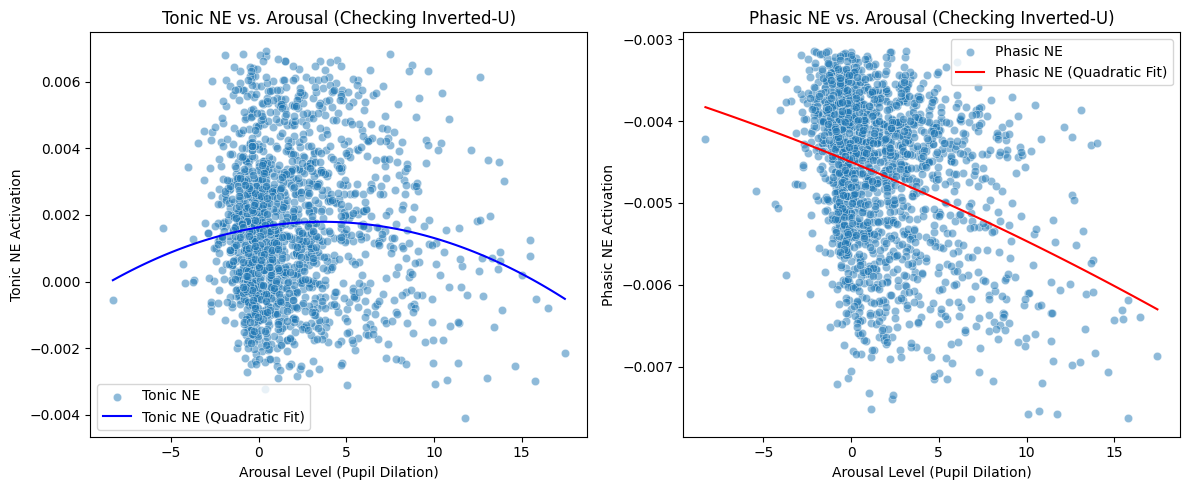


 Pearson Correlation with Actual Pupil Dilation:
LC: 0.066
NE: 0.241
Tonic_NE: -0.019
Phasic_NE: -0.334
Layer 1: 0.082
Layer 2: 0.153
Predicted Pupil Dilation: 0.447


In [41]:
analyze_ff_gadget_activations(ff_gadget, X_tensor, df_clean)

This model elarning representation is quite unstable

## Modified Uncertainty GadgetModel

Pupil Dilation MAE: 2.1842
Pupil Dilation MSE: 8.4304


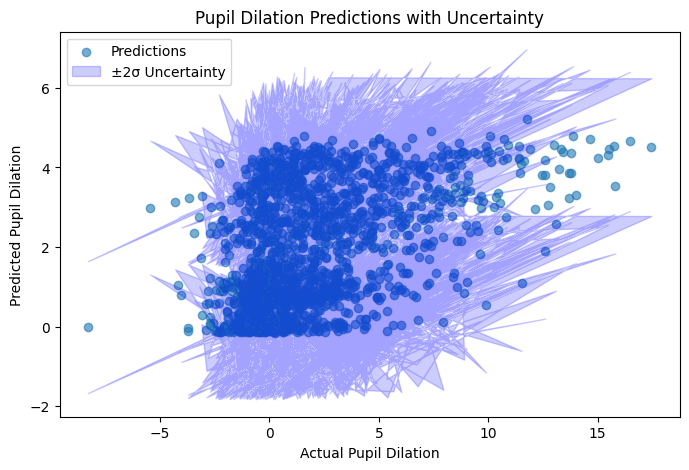

In [42]:
evaluate_ff_uncertainty_gadget(ff_uncertain_gadget, X_tensor, Y_tensor, scaler_Y)

In [43]:
from analysis.analysis import (extract_activations,
                               compute_mapper_graph,
                               compute_persistent_homology)

Analyzing LC activations...


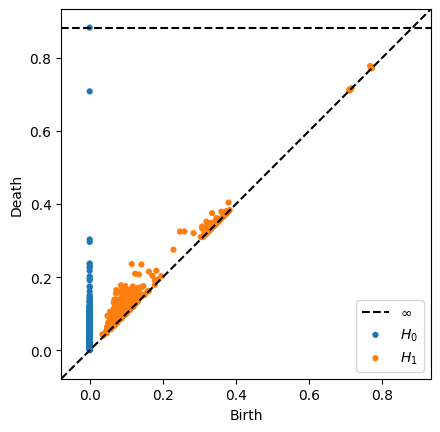

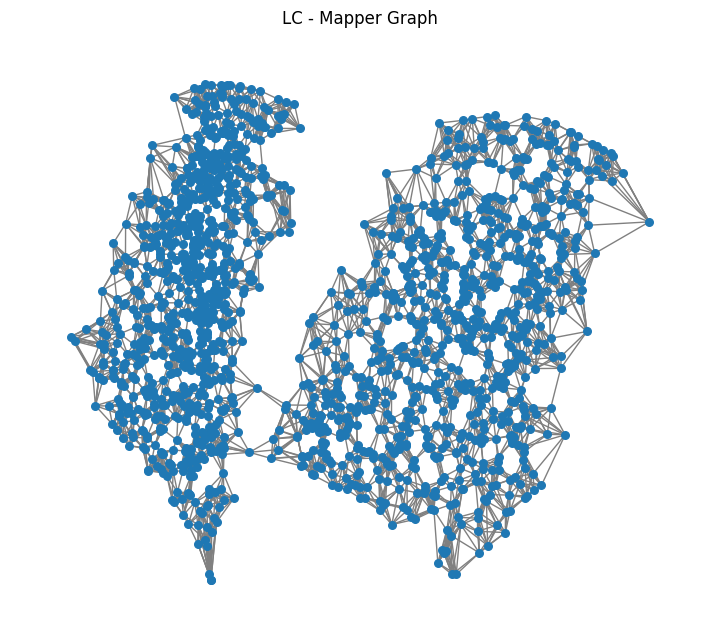

Analyzing NE activations...


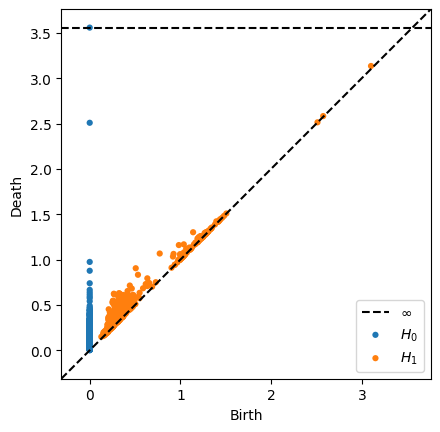

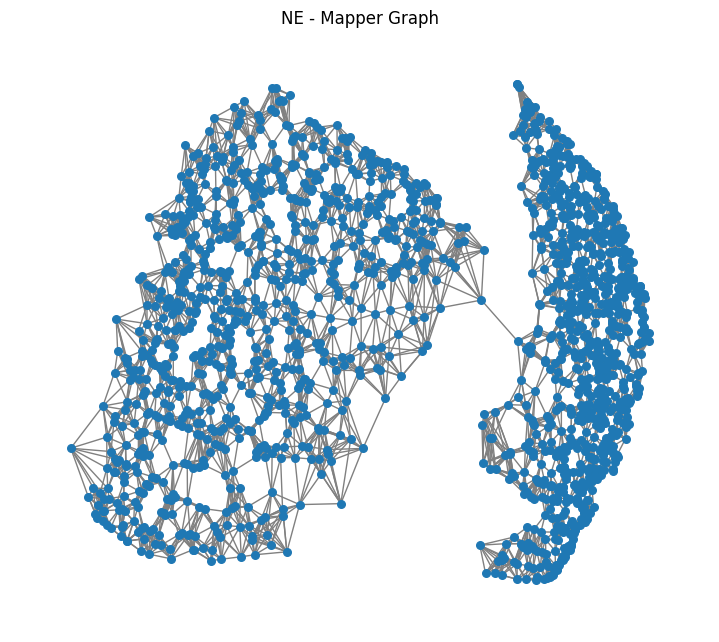

Analyzing Tonic_NE activations...


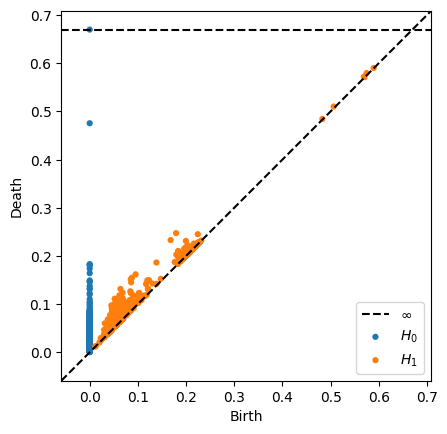

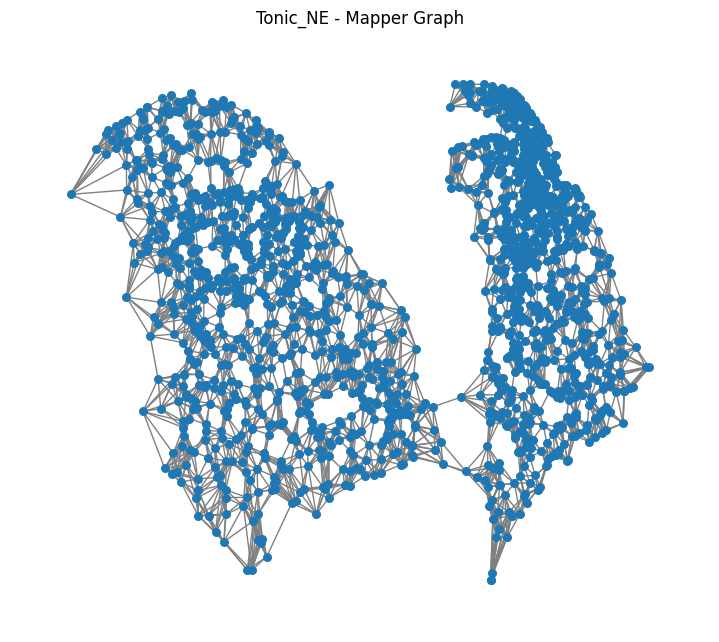

Analyzing Phasic_NE activations...


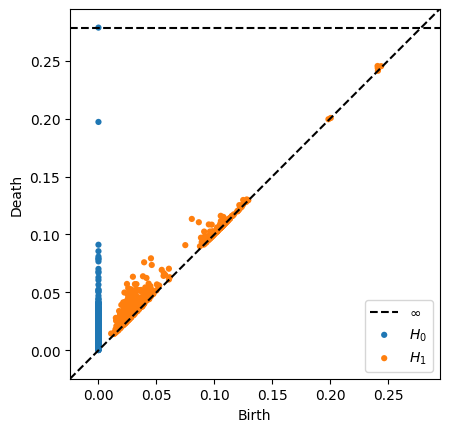

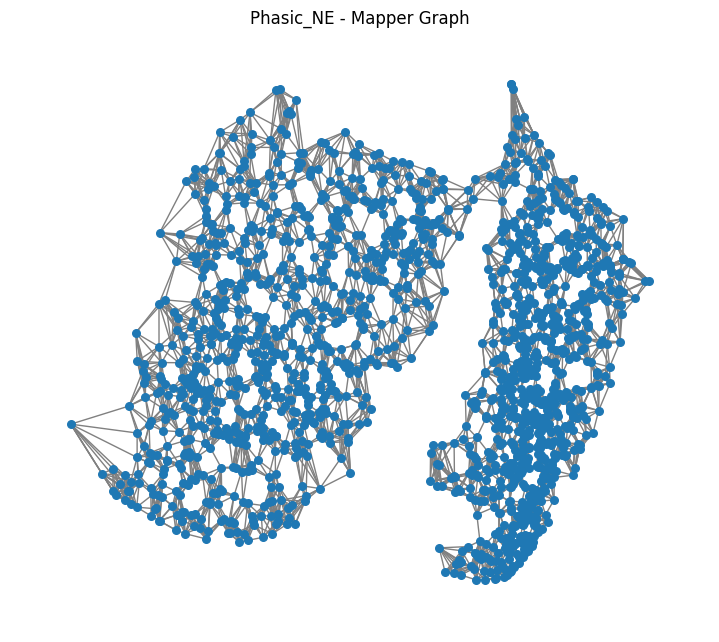

Analyzing Hidden_1 activations...


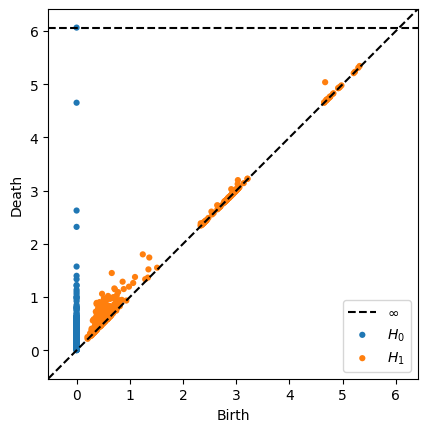

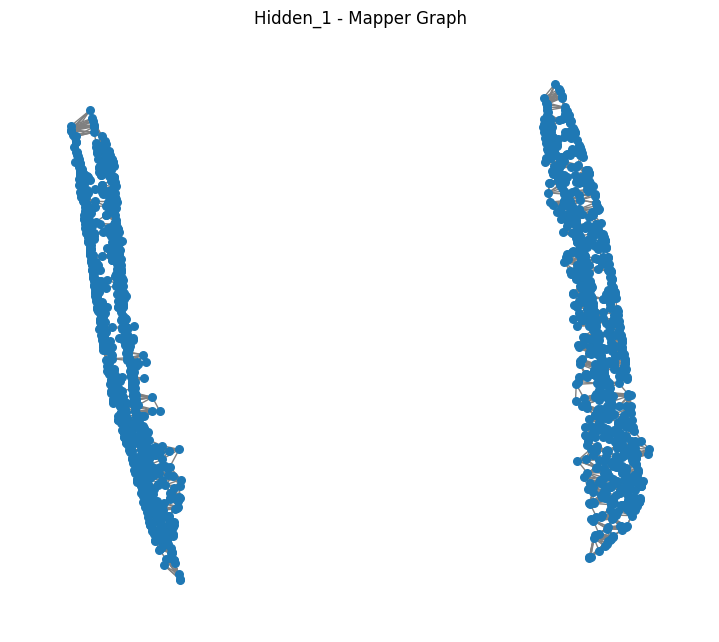

Analyzing Hidden_2 activations...


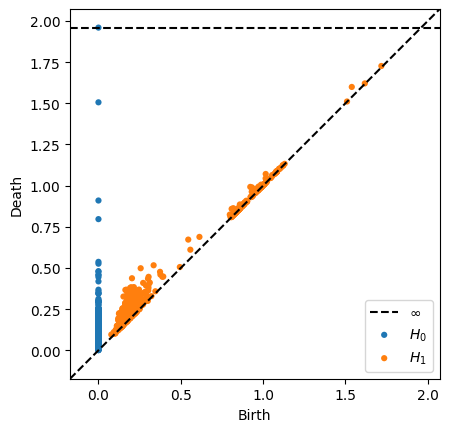

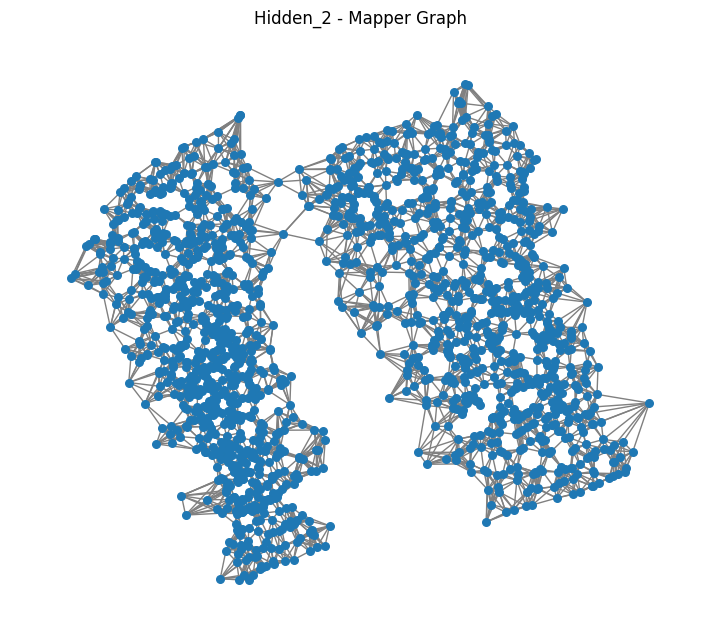

In [44]:
activations = extract_activations(ff_uncertain_gadget, X_tensor)

for key, act in activations.items():
    print(f"Analyzing {key} activations...")
    compute_persistent_homology(act, title=f"{key} - Persistent Homology")
    compute_mapper_graph(act, title=f"{key} - Mapper Graph")
